**IMPORT LIBRARIES**

In [176]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' # Suppresses all warning messages

import numpy as np
import joblib
import random
import pandas as pd 
import matplotlib.pyplot as plt 
import tensorflow as tf 


from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score


**REPRODUCIBILITY**

In [177]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

**CREATE OUTPUT DIRECTORIES**

In [178]:
os.makedirs("../models", exist_ok=True)
os.makedirs("../result", exist_ok=True)

**LOAD DATASET**

In [179]:
df = pd.read_csv("../data/Churn_Modelling.csv")

print("\nDataset loaded successfully.")

print("\nFirst 5 rows:")
print(df.head())


Dataset loaded successfully.

First 5 rows:
   RowNumber  CustomerId   Surname  ...  IsActiveMember EstimatedSalary Exited
0          1    15634602  Hargrave  ...               1       101348.88      1
1          2    15647311      Hill  ...               1       112542.58      0
2          3    15619304      Onio  ...               0       113931.57      1
3          4    15701354      Boni  ...               0        93826.63      0
4          5    15737888  Mitchell  ...               1        79084.10      0

[5 rows x 14 columns]


**EXPLORE DATASET**

In [180]:
print("Dataset shape:", df.shape)

print("\nDataset information:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nTarget distribution:")
print(df["Exited"].value_counts())

print("\nTarget distribution percentage:")
print(
    df["Exited"]
    .value_counts(normalize=True)
    .mul(100)
)


Dataset shape: (10000, 14)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None

Missing values:
RowNumber          0
Cu

**DROP UNNECESSARY COLUMNS**

In [181]:
df = df.drop(
    ["RowNumber",
     "CustomerId",
     "Surname"],
     axis=1
)

**ENCODE GENDER**

In [182]:
le = LabelEncoder()

df['Gender'] = le.fit_transform(
    df['Gender']
)

**ONE-HOT ENCODE GEOGRAPHY**

In [183]:
df = pd.get_dummies(
    df,
    columns=["Geography"],
    drop_first=True
)

for column in df.columns:

    if df[column].dtype == bool:

        df[column] = df[column].astype(int)

**SEPARATE FEATURES AND LABELS**

In [184]:
X = df.drop(
    "Exited",
    axis=1
)

y = df["Exited"]

print("\nFeature columns:")
print(X.columns.tolist())


print("\nNumber of features:", X.shape[1])


Feature columns:
['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain']

Number of features: 11


**TRAIN-TEST SPLIT**

In [185]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

**VALIDATION SPLIT**

In [186]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train
)

**DATASET SPLIT SHAPE**

In [187]:
print("\nDataset split:")

print(
    "Training:",
    X_train.shape
)

print(
    "Validation:",
    X_val.shape
)

print(
    "Testing:",
    X_test.shape
)


Dataset split:
Training: (6400, 11)
Validation: (1600, 11)
Testing: (2000, 11)


**FEATURE SCALING**

In [188]:
scaler = StandardScaler()

# Fit scaler ONLY on training data
X_train = scaler.fit_transform(X_train)

# Transform validation and test using the same scaler
X_test = scaler.transform(X_test)

X_val = scaler.transform(X_val)

# Save scaler
joblib.dump(
    scaler,
    "../models/scaker.pkl"
)

['../models/scaker.pkl']

**MODEL BUILDING FUNCTION**

In [189]:
def build_model(
    architecture=(64, 32, 16),
    learning_rate=0.001,
    optimizer_name="adam",
    dropout_rate=0.0,
    activation="relu"
):

    # Clear previous TensorFlow model
    tf.keras.backend.clear_session()

    # Create model
    model = tf.keras.Sequential()

    # Input layer
    model.add(
        tf.keras.layers.Input(
            shape=(X_train.shape[1] ,)
        )
    )

	# Hidden layers
    for units in architecture:

        model.add(
            tf.keras.layers.Dense(units=units, activation=activation)
        )

        # Add dropout if requested
        if dropout_rate > 0:

            model.add(
                tf.keras.layers.Dropout(dropout_rate)
            )
    
    # Output layer
    model.add(
        tf.keras.layers.Dense(
            units=1,
            activation="sigmoid"
        )
    )

    # OPTIMIZER SELECTION
    if optimizer_name == "adam":

        optimizer = tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        )

    elif optimizer_name == "sgd":

        optimizer = tf.keras.optimizers.SGD(
            learning_rate=learning_rate
        )

    elif optimizer_name == "rmsprop":

        optimizer = tf.keras.optimizers.RMSprop(
            learning_rate=learning_rate
        )

    else:
        raise ValueError(
            f"Unsupported optimizer: {optimizer_name}"
        )


    # Compile Model
    model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
    )

    return model

    

**EXPERIMENT FUNCTION**

In [190]:
def run_experiment(
        experiment_name,
        architecture=(64, 32, 16),
        learning_rate=0.001,
        optimizer_name="adam",
        dropout_rate=0.0,
        activation="relu",
        batch_size=32,
        epochs=50
):
    print("\n")
    print("=" * 70)
    print("EXPERIMENT:", experiment_name)

    # Build model
    model = build_model(
        architecture=architecture,
        learning_rate=learning_rate,
        optimizer_name=optimizer_name,
        dropout_rate=dropout_rate,
        activation=activation,
    )

    # EARLY STOPPING
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True
    )

    # TRAIN MODEL
    history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[
        early_stopping
    ],
    verbose=0
    )

    # VALIDATION PERFORMANCE
    val_loss, val_accuracy = model.evaluate(
        X_val,
        y_val,
        verbose=0
    )

    # TEST PERFORMANCE
    test_loss, test_accuracy = model.evaluate(
        X_test,
        y_test,
        verbose=0
    )

    # PREDICTIONS
    probabilities = model.predict(
        X_test,
        verbose=0
    ).ravel()

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    # CLASSIFICATION METRICS
    report = classification_report(
        y_test,
        predictions,
        output_dict=True,
        zero_division=0
    )

    precision = report[
        "weighted avg"
    ]["precision"]


    recall = report[
        "weighted avg"
    ]["recall"]


    f1 = report[
        "weighted avg"
    ]["f1-score"]

    # STORE RESULTS
    result = {

        "Experiment":
            experiment_name,

        "Optimizer":
            optimizer_name,

        "Learning Rate":
            learning_rate,

        "Architecture":
            str(architecture),

        "Activation":
            activation,

        "Dropout":
            dropout_rate,

        "Batch Size":
            batch_size,

        "Epochs":
            len(
                history.history["loss"]
            ),

        "Validation Accuracy":
            val_accuracy,

        "Test Accuracy":
            test_accuracy,

        "Precision":
            precision,

        "Recall":
            recall,

        "F1 Score":
            f1,

        "Test Loss":
            test_loss

    }

    print(
        f"Validation Accuracy: "
        f"{val_accuracy:.4f}"
    )

    print(
        f"Test Accuracy: "
        f"{test_accuracy:.4f}"
    )

    print(
        f"F1 Score: "
        f"{f1:.4f}"
    )


    return model, history, result


**RESULTS STORAGE**

In [191]:
results = []

**BASELINE MODEL**

In [192]:
baseline_model, baseline_history, baseline_result = run_experiment(
    experiment_name="Baseline",
    architecture=(64, 32, 16),
    learning_rate=0.001,
    optimizer_name="adam",
    dropout_rate=0.0,
    activation="relu",
    batch_size=32,
    epochs=50
)

results.append(baseline_result)



EXPERIMENT: Baseline
Validation Accuracy: 0.8581
Test Accuracy: 0.8650
F1 Score: 0.8511


**LEARNING RATE EXPERIMENTS**

In [193]:
learning_rates = [
    0.01,
    0.001,
    0.0001
]

for lr in learning_rates:

    model, experiment, result = run_experiment(
        experiment_name=f"Learning Rate {lr}",
        architecture=(64, 32, 16),
        learning_rate=lr,
        optimizer_name="adam",
        dropout_rate=0.0,
        activation="relu",
        batch_size=32,
        epochs=50
    )

    results.append(result)



EXPERIMENT: Learning Rate 0.01
Validation Accuracy: 0.8550
Test Accuracy: 0.8620
F1 Score: 0.8439


EXPERIMENT: Learning Rate 0.001
Validation Accuracy: 0.8531
Test Accuracy: 0.8615
F1 Score: 0.8493


EXPERIMENT: Learning Rate 0.0001
Validation Accuracy: 0.8537
Test Accuracy: 0.8665
F1 Score: 0.8543


**OPTIMIZER EXPERIMENTS**

In [194]:
optimizers = [
    "adam",
    "sgd",
    "rmsprop"
]

for optimizer in optimizers:

    model, experiment, result = run_experiment(

        experiment_name=f"Optimizer {optimizer}",
        architecture=(64, 32, 16),
        learning_rate=0.001,
        optimizer_name=optimizer,
        dropout_rate=0.0,
        activation="relu",
        batch_size=32,
        epochs=50
    )

    results.append(result)



EXPERIMENT: Optimizer adam
Validation Accuracy: 0.8569
Test Accuracy: 0.8640
F1 Score: 0.8506


EXPERIMENT: Optimizer sgd
Validation Accuracy: 0.7962
Test Accuracy: 0.7965
F1 Score: 0.7063


EXPERIMENT: Optimizer rmsprop
Validation Accuracy: 0.8512
Test Accuracy: 0.8625
F1 Score: 0.8510


**ARCHITECTURE EXPERIMENTS**

In [195]:
architectures = [

    (32, 16, 8),

    (64, 32, 16),

    (128, 64, 32),

    (128, 64, 32, 16)

]

for architecture in architectures:

    model, history, result = run_experiment(

        experiment_name=f"Architecture {architecture}",

        architecture=architecture,

        learning_rate=0.001,

        optimizer_name="adam",

        dropout_rate=0.0,

        activation="relu",

        batch_size=32,

        epochs=50

    )

    results.append(result)



EXPERIMENT: Architecture (32, 16, 8)
Validation Accuracy: 0.8606
Test Accuracy: 0.8635
F1 Score: 0.8488


EXPERIMENT: Architecture (64, 32, 16)
Validation Accuracy: 0.8512
Test Accuracy: 0.8650
F1 Score: 0.8517


EXPERIMENT: Architecture (128, 64, 32)
Validation Accuracy: 0.8594
Test Accuracy: 0.8585
F1 Score: 0.8462


EXPERIMENT: Architecture (128, 64, 32, 16)
Validation Accuracy: 0.8525
Test Accuracy: 0.8625
F1 Score: 0.8506


**BATCH SIZE EXPERIMENTS**

In [196]:
batch_sizes = [

    16,

    32,

    64,

    128

]

for batch_size in batch_sizes:

    model, experiment, result = run_experiment(
        experiment_name=f"Batch Size {batch_size}",

        architecture=(64, 32, 16),

        learning_rate=0.001,

        optimizer_name="adam",

        dropout_rate=0.0,

        activation="relu",

        batch_size=batch_size,

        epochs=50
)

    results.append(result)



EXPERIMENT: Batch Size 16
Validation Accuracy: 0.8550
Test Accuracy: 0.8520
F1 Score: 0.8413


EXPERIMENT: Batch Size 32
Validation Accuracy: 0.8556
Test Accuracy: 0.8590
F1 Score: 0.8444


EXPERIMENT: Batch Size 64
Validation Accuracy: 0.8531
Test Accuracy: 0.8635
F1 Score: 0.8508


EXPERIMENT: Batch Size 128
Validation Accuracy: 0.8600
Test Accuracy: 0.8610
F1 Score: 0.8452


**DROPOUT EXPERIMENTS**

In [197]:
dropout_rates = [

    0.0,

    0.2,

    0.3,

    0.5

]

for dropout in dropout_rates:

    model, experiment, result = run_experiment(

        experiment_name=f"Dropout {dropout}",

        architecture=(64, 32, 16),

        learning_rate=0.001,

        optimizer_name="adam",

        dropout_rate=dropout,

        activation="relu",

        batch_size=32,

        epochs=50
    )

    results.append(result)



EXPERIMENT: Dropout 0.0
Validation Accuracy: 0.8569
Test Accuracy: 0.8645
F1 Score: 0.8506


EXPERIMENT: Dropout 0.2
Validation Accuracy: 0.8550
Test Accuracy: 0.8695
F1 Score: 0.8563


EXPERIMENT: Dropout 0.3
Validation Accuracy: 0.8544
Test Accuracy: 0.8605
F1 Score: 0.8443


EXPERIMENT: Dropout 0.5
Validation Accuracy: 0.8550
Test Accuracy: 0.8635
F1 Score: 0.8457


**ACTIVATION FUNCTION EXPERIMENTS**

In [198]:
activations = [

    "relu",

    "tanh"

]

for activation in activations:

    model, history, result = run_experiment(

        experiment_name=f"Activation {activation}",

        architecture=(64, 32, 16),

        learning_rate=0.001,

        optimizer_name="adam",

        dropout_rate=0.2,

        activation=activation,

        batch_size=32,

        epochs=50

    )

    results.append(result)



EXPERIMENT: Activation relu
Validation Accuracy: 0.8550
Test Accuracy: 0.8690
F1 Score: 0.8567


EXPERIMENT: Activation tanh
Validation Accuracy: 0.8669
Test Accuracy: 0.8675
F1 Score: 0.8539


**CREATE RESULTS DATAFRAME**

In [199]:
results_df = pd.DataFrame(
    results
)

# Sort by validation accuracy
results_df = results_df.sort_values(
    by="Validation Accuracy",
    ascending=False

).reset_index(
    drop=True
)

**DISPLAY RESULTS**

In [200]:
print("\n")
print("=" * 70)
print("HYPERPARAMETER EXPERIMENT RESULTS")
print("=" * 70)

print(
    results_df.to_string(
        index=False
    )
)




HYPERPARAMETER EXPERIMENT RESULTS
                    Experiment Optimizer  Learning Rate      Architecture Activation  Dropout  Batch Size  Epochs  Validation Accuracy  Test Accuracy  Precision  Recall  F1 Score  Test Loss
               Activation tanh      adam         0.0010      (64, 32, 16)       tanh      0.2          32      43             0.866875         0.8675   0.860544  0.8675  0.853919   0.334229
      Architecture (32, 16, 8)      adam         0.0010       (32, 16, 8)       relu      0.0          32      23             0.860625         0.8635   0.855784  0.8635  0.848826   0.348130
                Batch Size 128      adam         0.0010      (64, 32, 16)       relu      0.0         128      24             0.860000         0.8610   0.853026  0.8610  0.845226   0.343433
    Architecture (128, 64, 32)      adam         0.0010     (128, 64, 32)       relu      0.0          32      13             0.859375         0.8585   0.848333  0.8585  0.846245   0.345246
              

**SAVE RESULTS**

In [201]:
results_df.to_csv(
    "../result/experiment_results.csv",
    index=False
)

**SELECT BEST MODEL CONFIGURATION**

In [202]:
best_result = results_df.iloc[0]

print("\n")
print("=" * 70)
print("BEST CONFIGURATION")
print("=" * 70)


print(
    "Experiment:",
    best_result["Experiment"]
)

print(
    "Optimizer:",
    best_result["Optimizer"]
)

print(
    "Architecture:",
    best_result["Architecture"]
)

print(
    "Activation:",
    best_result["Activation"]
)

print(
    "Dropout:",
    best_result["Dropout"]
)

print(
    "Batch Size:",
    best_result["Batch Size"]
)

print(
    "Validation Accuracy:",
    f"{best_result['Validation Accuracy']:.4f}"
)





BEST CONFIGURATION
Experiment: Activation tanh
Optimizer: adam
Architecture: (64, 32, 16)
Activation: tanh
Dropout: 0.2
Batch Size: 32
Validation Accuracy: 0.8669


**PARSE BEST PARAMETERS**

In [203]:
best_architecture = eval(
    best_result["Architecture"]
)

best_learning_rate = float(
    best_result["Learning Rate"]
)

best_optimizer = best_result[
    "Optimizer"
]

best_activation = best_result[
    "Activation"
]

best_dropout = float(
    best_result["Dropout"]
)

best_batch_size = int(
    best_result["Batch Size"]
)

**BUILD FINAL MODEL**

In [204]:
final_model = build_model(
    architecture=best_architecture,
    learning_rate=best_learning_rate,
    optimizer_name=best_optimizer,
    dropout_rate=best_dropout,
    activation=best_activation
)

**FINAL MODEL TRAINING**

In [205]:
final_early_stopping = tf.keras.callbacks.EarlyStopping(

    monitor="val_loss",

    patience=10,

    restore_best_weights=True

)

final_history = final_model.fit(

    X_train,

    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=100,

    batch_size=best_batch_size,

    callbacks=[
        final_early_stopping
    ],

    verbose=1
)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7552 - loss: 0.5045 - val_accuracy: 0.8231 - val_loss: 0.4263
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8072 - loss: 0.4373 - val_accuracy: 0.8338 - val_loss: 0.4155
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8116 - loss: 0.4258 - val_accuracy: 0.8344 - val_loss: 0.3921
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8220 - loss: 0.4073 - val_accuracy: 0.8400 - val_loss: 0.3788
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8259 - loss: 0.3985 - val_accuracy: 0.8444 - val_loss: 0.3698
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8278 - loss: 0.3944 - val_accuracy: 0.8481 - val_loss: 0.3661
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8361 - loss: 0.3888 - val_accuracy: 0.8562 - val_loss: 0.3630
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8373 - loss: 0.3815 - val_accu

**FINAL TEST EVALUATION**

In [206]:
final_loss, final_accuracy = final_model.evaluate(

    X_test,

    y_test,

    verbose=0

)

print("\n")
print("=" * 70)
print("FINAL MODEL PERFORMANCE")
print("=" * 70)

print(
    f"Test Loss: {final_loss:.4f}"
)

print(
    f"Test Accuracy: "
    f"{final_accuracy:.4f}"
)

print(
    f"Test Accuracy: "
    f"{final_accuracy * 100:.2f}%"
)



FINAL MODEL PERFORMANCE
Test Loss: 0.3383
Test Accuracy: 0.8645
Test Accuracy: 86.45%


**FINAL PREDICTIONS**

In [207]:
final_probabilities = final_model.predict(

    X_test,

    verbose=0

).ravel()


final_predictions = (

    final_probabilities >= 0.5

).astype(int)

**CLASSIFICATION REPORT**

In [208]:
print("\n")
print("=" * 70)
print("FINAL CLASSIFICATION REPORT")
print("=" * 70)

print(

    classification_report(

        y_test,

        final_predictions,

        target_names=[
            "Stayed",
            "Churned"
        ],

        zero_division=0

    )

)



FINAL CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Stayed       0.88      0.97      0.92      1593
     Churned       0.78      0.47      0.58       407

    accuracy                           0.86      2000
   macro avg       0.83      0.72      0.75      2000
weighted avg       0.86      0.86      0.85      2000



**CONFUSION MATRIX**

In [209]:
cm = confusion_matrix(

    y_test,

    final_predictions

)


print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[1539   54]
 [ 217  190]]


**CONFUSION MATRIX VISUALIZATION**

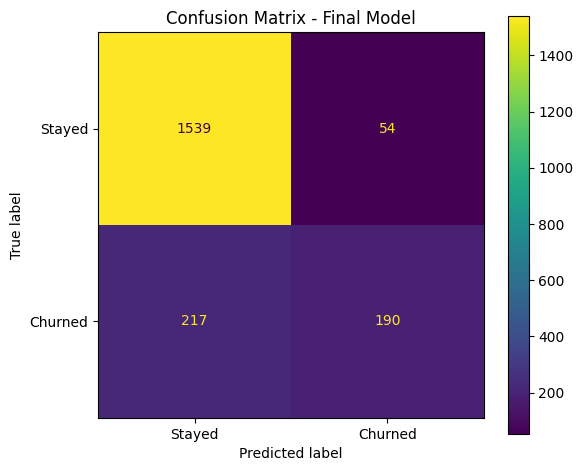

In [210]:
disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=[
        "Stayed",
        "Churned"
    ]

)


fig, ax = plt.subplots(
    figsize=(6, 5)
)

disp.plot(
    ax=ax
)

plt.title(
    "Confusion Matrix - Final Model"
)

plt.tight_layout()

plt.savefig(

    "../result/confusion_matrix.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

**FINAL ACCURACY CURVE**

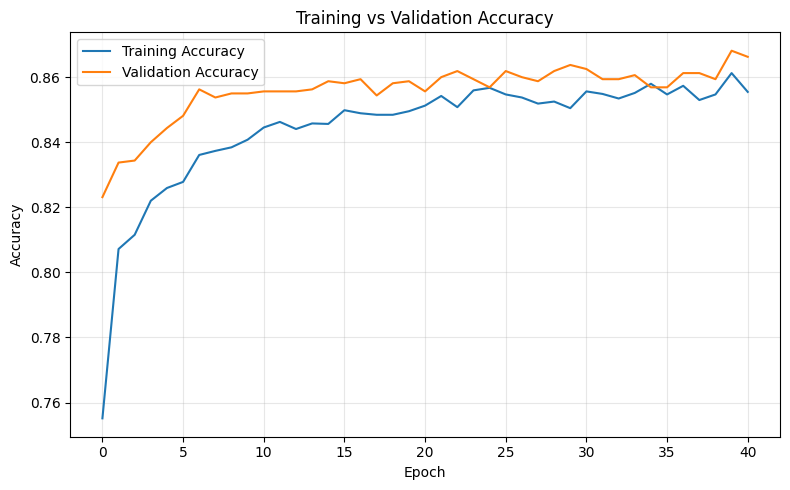

In [211]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(

    final_history.history["accuracy"],

    label="Training Accuracy"

)

plt.plot(

    final_history.history["val_accuracy"],

    label="Validation Accuracy"

)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "Training vs Validation Accuracy"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(

    "../result/accuracy_curve.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

**FINAL LOSS CURVE**

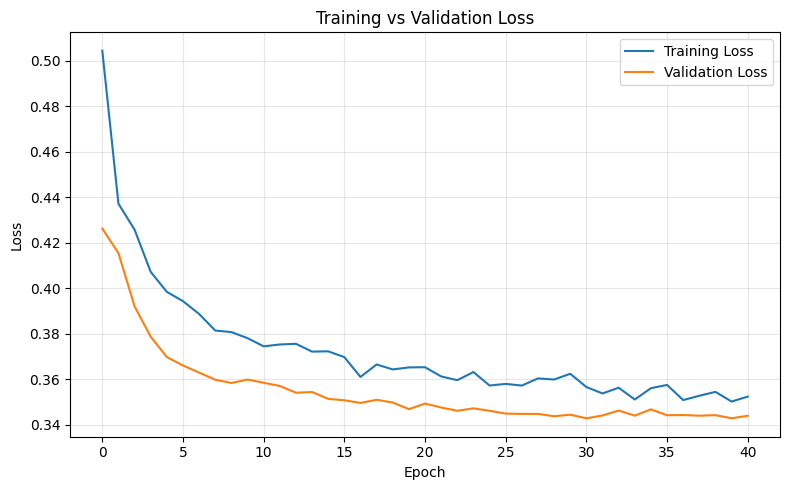

In [212]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(

    final_history.history["loss"],

    label="Training Loss"

)

plt.plot(

    final_history.history["val_loss"],

    label="Validation Loss"

)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "Training vs Validation Loss"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(

    "../result/loss_curve.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

**HYPERPARAMETER COMPARISON**

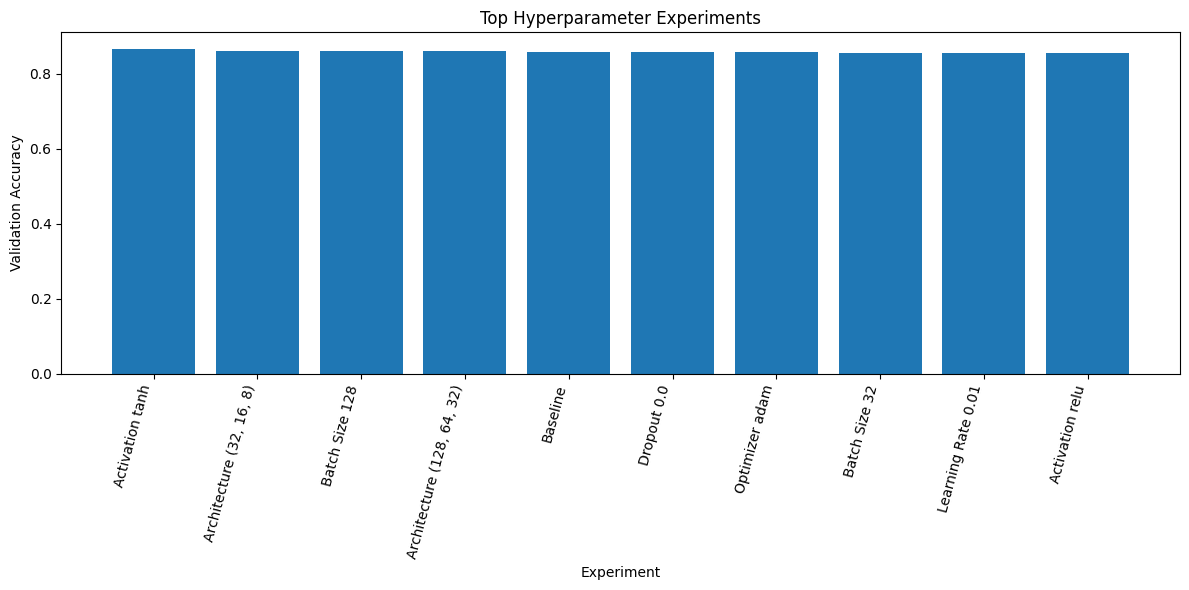

In [213]:
top_results = results_df.head(10)


plt.figure(
    figsize=(12, 6)
)

plt.bar(

    top_results["Experiment"],

    top_results["Validation Accuracy"]

)

plt.xticks(

    rotation=75,

    ha="right"

)

plt.ylabel(
    "Validation Accuracy"
)

plt.xlabel(
    "Experiment"
)

plt.title(
    "Top Hyperparameter Experiments"
)

plt.tight_layout()

plt.savefig(

    "../result/hyperparameter_comparison.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

**BASELINE VS FINAL MODEL**

In [214]:
baseline_accuracy = baseline_result[
    "Test Accuracy"
]


improvement = (

    final_accuracy -
    baseline_accuracy

)


print("\n")
print("=" * 70)
print("BASELINE VS TUNED MODEL")
print("=" * 70)

print(
    f"Baseline Accuracy: "
    f"{baseline_accuracy:.4f}"
)

print(
    f"Tuned Accuracy: "
    f"{final_accuracy:.4f}"
)

print(
    f"Improvement: "
    f"{improvement:.4f}"
)

print(
    f"Improvement: "
    f"{improvement * 100:.2f} percentage points"
)



BASELINE VS TUNED MODEL
Baseline Accuracy: 0.8650
Tuned Accuracy: 0.8645
Improvement: -0.0005
Improvement: -0.05 percentage points


**SAVE FINAL MODEL**

In [215]:
final_model.save(
    "../models/best_churn_model.keras"
)

**SAVE BEST CONFIGURATION**

In [216]:
best_configuration = pd.DataFrame([

    {

        "Architecture":
            str(best_architecture),

        "Optimizer":
            best_optimizer,

        "Learning Rate":
            best_learning_rate,

        "Activation":
            best_activation,

        "Dropout":
            best_dropout,

        "Batch Size":
            best_batch_size,

        "Test Accuracy":
            final_accuracy

    }

])


best_configuration.to_csv(

    "../result/best_model_configuration.csv",

    index=False

)

**SAMPLE CUSTOMER PREDICTION**

In [217]:
print("\n")
print("=" * 70)
print("SAMPLE CUSTOMER PREDICTION")
print("=" * 70)


sample_customer = pd.DataFrame({

    "CreditScore": [650],

    "Gender": [1],

    "Age": [40],

    "Tenure": [5],

    "Balance": [100000],

    "NumOfProducts": [2],

    "HasCrCard": [1],

    "IsActiveMember": [1],

    "EstimatedSalary": [60000],

    "Geography_Germany": [0],

    "Geography_Spain": [0]

})

# Ensure identical column order
sample_customer = sample_customer[
    X.columns
]


# Scale sample
sample_scaled = scaler.transform(
    sample_customer
)


# Predict
churn_probability = (

    final_model.predict(

        sample_scaled,

        verbose=0

    )[0][0]

)


print(
    f"Churn Probability: "
    f"{churn_probability:.2%}"
)


if churn_probability >= 0.5:

    print(
        "Prediction: Customer is likely to CHURN."
    )

else:

    print(
        "Prediction: Customer is likely to STAY."
    )





SAMPLE CUSTOMER PREDICTION
Churn Probability: 6.04%
Prediction: Customer is likely to STAY.


**FINAL PROJECT SUMMARY**

In [218]:
print("\n")
print("=" * 70)
print("PROJECT COMPLETED")
print("=" * 70)

print(
    f"Baseline Accuracy: "
    f"{baseline_accuracy:.2%}"
)

print(
    f"Final Tuned Accuracy: "
    f"{final_accuracy:.2%}"
)

print(
    f"Improvement: "
    f"{improvement * 100:.2f} percentage points"
)

print("\nGenerated files:")

print(
    "../models/baseline_model.keras"
)

print(
    "../models/best_churn_model.keras"
)

print(
    "../models/scaler.pkl"
)

print(
    "../result/experiment_results.csv"
)

print(
    "../result/best_model_configuration.csv"
)

print(
    "../result/confusion_matrix.png"
)

print(
    "../result/accuracy_curve.png"
)

print(
    "../result/loss_curve.png"
)

print(
    "../result/hyperparameter_comparison.png"
)

print("\nAll experiments completed successfully.")



PROJECT COMPLETED
Baseline Accuracy: 86.50%
Final Tuned Accuracy: 86.45%
Improvement: -0.05 percentage points

Generated files:
../models/baseline_model.keras
../models/best_churn_model.keras
../models/scaler.pkl
../result/experiment_results.csv
../result/best_model_configuration.csv
../result/confusion_matrix.png
../result/accuracy_curve.png
../result/loss_curve.png
../result/hyperparameter_comparison.png

All experiments completed successfully.
